# Performance outcome during training

Replicates the "success rate" figures from the older `Q_C_Analysis_Workflow`
(`make_outcome_df` / `plot_outcome_rate` in `C_modified_figures.ipynb`, and the
within-day helpers in `updated_figures.ipynb`), but driven by the **qc pipeline** so
session selection and trial filtering have a single source of truth.

Two session lists are loaded (see `training_filter.py`):
- **`TRAINING_DETAIL`** (5-day D1-D5): the "Session 1-5" axis for the rate curves.
- **`TRAINING_FIRST_MID_LAST_DETAIL`** (first / middle / last training day): for the
  within-session and search-path-duration figures (matches `Requested_plots.ipynb`).

**Figures**
1. Performance outcome during training: Success / Miss / Failure rate per session.
2. Within-session performance (cumulative): first / mid / last day, pooled by group.
3. Performance vs search-path duration (TTT bins), per-mouse + mean.
4. Shaping days per mouse (needs the folder counts from the data PC, see that section).

Like `Requested_plots.ipynb`, this loads from the external training tree, so run it on
the machine that has the data.

In [1]:
# Initial setup
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from data_conduit.qc import (
    qc_datastructure,
    training_spec,
    training_session_names,
    filter_trials,
    summarise_training_filter,
    TRAINING_DETAIL,
    TRAINING_FIRST_MID_LAST_DETAIL,
    TRAINING_PHASE_LABELS,
)

# Training data root (same external tree as Requested_plots.ipynb). Sessions are
# selected by Bonsai filename via `include=` below, NOT by the on-disk Day<N> folder.
ROOT = pathlib.Path('/media/sepi/Elements1/PathIntegrationProtocol/BonsaiOutput/Training')

In [2]:
# Session selection (step 1 of 2)
# Build BOTH specs and load the UNION of their sessions in one pass:
#   * spec_sessions : 5-day D1-D5 (default TRAINING_DETAIL) -> Figure 1 rate curves.
#   * spec_phase    : first / mid / last day -> Figures 2 and 3.
# training_day means the calendar day (1..5) in spec_sessions, and the PHASE (1=first,
# 2=mid, 3=last) in spec_phase; a phase label is attached for readable plot axes.
spec_sessions = training_spec()                                   # TRAINING_DETAIL
spec_phase = training_spec(TRAINING_FIRST_MID_LAST_DETAIL)        # first / mid / last
spec_phase['phase'] = spec_phase['training_day'].map(TRAINING_PHASE_LABELS)

include = list(dict.fromkeys(                                     # de-duplicated union, spec order
    training_session_names(spec_sessions) + training_session_names(spec_phase)
))

datastructure = qc_datastructure(
    root = ROOT,
    depth = 2,                                                    # <mouseID>/<day>/<session>
    level_names = ('mouseID', 'day'),                             # provenance columns kept on every entry
    streams = ('events', 'nosepoke', 'soundcard', 'session_settings'),   # only the trial table is needed
    include = include,
)

result = datastructure.load()   # apply the catalog to each session and concatenate
trials = result['trials']       # unfiltered: every trial of every selected session
trials


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  


,trial_index,start_time,end_time,tz_triggered_time,outbound_start_time,outbound_end_time,inbound_start_time,inbound_end_time,TTT,TTP,ChosenPort,CorrectPort,outcome,LED,angle_offset,target_zone_size,session,mouseID,day
0,1,22852.592992,22879.349984,22874.800992,22852.592992,22874.800992,22874.800992,22879.349984,22.208000,4.548992,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
1,2,22879.349984,22923.335488,22921.252000,22879.349984,22921.252000,22921.252000,22923.335488,41.902016,2.083488,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
2,3,22923.335488,22935.201984,22932.852992,22923.335488,22932.852992,22932.852992,22935.201984,9.517504,2.348992,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
3,4,22935.201984,22945.540000,22944.252000,22935.201984,22944.252000,22944.252000,22945.540000,9.050016,1.288000,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
4,5,22945.540000,22955.582464,22954.052000,22945.540000,22954.052000,22954.052000,22955.582464,8.512000,1.530464,14,14,Success,ON,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3062,60,16173.513984,16196.815488,16191.792000,16173.513984,16191.792000,16191.792000,16196.815488,18.278016,5.023488,-1,16,Miss,OFF,NaN,150.0,2026-05-14T135225Z,MbR_M01569518,Day9
3063,61,16196.815488,16374.456992,16369.442976,16196.815488,16369.442976,16369.442976,16374.456992,172.627488,5.014016,-1,16,Miss,OFF,NaN,150.0,2026-05-14T135225Z,MbR_M01569518,Day9
3064,62,16374.456992,16461.362976,16456.342976,16374.456992,16456.342976,16456.342976,16461.362976,81.885984,5.020000,-1,16,Miss,OFF,NaN,150.0,2026-05-14T135225Z,MbR_M01569518,Day9
3065,63,16461.362976,16474.692000,16472.442976,16461.362976,16472.442976,16472.442976,16474.692000,11.080000,2.249024,16,16,Success,OFF,NaN,150.0,2026-05-14T135225Z,MbR_M01569518,Day9


In [3]:
# Trial filtering (step 2 of 2)
# Apply each spec's per-session rules (keep trial_index >= min_trial, and drop ON cue
# trials for the block-protocol mice). filter_trials prints a per-session keep/drop
# summary and adds `training_day` plus `day_trial_index` (contiguous 1..N per mouse-day,
# pooling any combined sessions).
print('=== 5-day sessions (Figure 1) ===')
trials_sessions = filter_trials(trials, spec_sessions)

print('\n=== first / mid / last day (Figures 2 and 3) ===')
trials_phase = filter_trials(trials, spec_phase)
trials_phase['phase'] = trials_phase['training_day'].map(TRAINING_PHASE_LABELS)
trials_phase

=== 5-day sessions (Figure 1) ===
      mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
FLR_M01569521             1 2026-04-23T160907Z       74         11           64       False             0      64
FLR_M01569521             2 2026-04-25T190120Z       22         11           12       False             0      12
FLR_M01569521             2 2026-04-25T190915Z       73         11           63       False             0      63
FLR_M01569521             3 2026-04-28T124013Z       14          6            9       False             0       9
FLR_M01569521             3 2026-04-28T124547Z       68         11           58       False             0      58
FLR_M01569521             4 2026-04-29T161826Z      131         11          121       False             0     121
FLR_M01569521             5 2026-04-30T151438Z      109          6          104       False             0     104
 FL_M01569519             2 2026-05-11T125643Z       9

,trial_index,start_time,end_time,tz_triggered_time,outbound_start_time,outbound_end_time,inbound_start_time,inbound_end_time,TTT,TTP,...,outcome,LED,angle_offset,target_zone_size,session,mouseID,day,training_day,day_trial_index,phase
0,11,23009.675488,23021.869984,23016.854976,23009.675488,23016.854976,23016.854976,23021.869984,7.179488,5.015008,...,Miss,OFF,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2,1,1,first
1,12,23021.869984,23030.656000,23027.952992,23021.869984,23027.952992,23027.952992,23030.656000,6.083008,2.703008,...,Success,OFF,NaN,150.0,2026-04-23T160907Z,FLR_M01569521,Day2,1,2,first
2,13,23030.656000,23040.496480,23037.102976,23030.656000,23037.102976,23037.102976,23040.496480,6.446976,3.393504,...,Success,OFF,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2,1,3,first
3,14,23040.496480,23051.965984,23046.953984,23040.496480,23046.953984,23046.953984,23051.965984,6.457504,5.012000,...,Miss,OFF,0.0,150.0,2026-04-23T160907Z,FLR_M01569521,Day2,1,4,first
4,15,23051.965984,23066.218976,23061.202976,23051.965984,23061.202976,23061.202976,23066.218976,9.236992,5.016000,...,Miss,OFF,NaN,150.0,2026-04-23T160907Z,FLR_M01569521,Day2,1,5,first
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1173,109,15723.182976,15737.996480,15734.010976,15723.182976,15734.010976,15734.010976,15737.996480,10.828000,3.985504,...,Success,OFF,0.0,150.0,2026-06-09T132359Z,MbR_M01569518,Day22,3,82,last
1174,110,15737.996480,15751.428000,15747.010976,15737.996480,15747.010976,15747.010976,15751.428000,9.014496,4.417024,...,Success,OFF,0.0,150.0,2026-06-09T132359Z,MbR_M01569518,Day22,3,83,last
1175,111,15751.428000,15765.706976,15762.460992,15751.428000,15762.460992,15762.460992,15765.706976,11.032992,3.245984,...,Success,OFF,0.0,150.0,2026-06-09T132359Z,MbR_M01569518,Day22,3,84,last
1176,112,15765.706976,15787.080480,15784.260992,15765.706976,15784.260992,15784.260992,15787.080480,18.554016,2.819488,...,Success,OFF,0.0,150.0,2026-06-09T132359Z,MbR_M01569518,Day22,3,85,last


In [4]:
# Outcome-summary helpers (ported from Q_C_Analysis_Workflow/new/C_modified_figures.ipynb)
# ------------------------------------------------------------------------------------
# Each key in `outcome_filters` becomes two output columns: n_<key> (trials matching the
# listed outcomes) and prop_<key> (that count divided by n_total for the group).
outcome_filters = {
    'success': ['Success'],
    'miss': ['Miss'],
    'failure': ['Failure'],
    'success_or_failure': ['Success', 'Failure'],
}


def make_outcome_df(trials, outcome_filters, *, group_cols=('mouseID', 'training_day'),
                    outcome_col='outcome'):
    '''
    Summarise a trial table into per-group outcome counts and proportions.

    ----------
    Parameters:
        trials (pd.DataFrame):
            Trial-level table, one row per trial (e.g. the output of filter_trials).
        outcome_filters (dict[str, list[str]]):
            {name: [outcomes]} describing each numerator, e.g. {'success': ['Success']}.
            The name controls the output column names (n_<name>, prop_<name>); the list
            controls which rows count toward that numerator.
        group_cols (tuple[str]):
            Columns that define each group. Default ('mouseID', 'training_day').
        outcome_col (str):
            Name of the column holding trial outcomes. Default 'outcome'.
    Returns:
        pd.DataFrame:
            One row per group, with n_total and one n_<name> / prop_<name> pair per filter.
    '''
    group_cols = list(group_cols)

    # Denominator: total trials in each group.
    outcome_df = trials.groupby(group_cols).size().rename('n_total').reset_index()

    # One count + proportion column per requested filter.
    for name, outcomes in outcome_filters.items():
        counts = (
            trials[trials[outcome_col].isin(outcomes)]
            .groupby(group_cols).size().rename(f'n_{name}').reset_index()
        )
        outcome_df = outcome_df.merge(counts, on=group_cols, how='left')
        outcome_df[f'n_{name}'] = outcome_df[f'n_{name}'].fillna(0).astype(int)
        outcome_df[f'prop_{name}'] = outcome_df[f'n_{name}'] / outcome_df['n_total']

    return outcome_df


def add_session_index(trials, *, mouse_col='mouseID', day_col='training_day',
                      session_col='session_index'):
    '''
    Add a per-mouse 1..N `session_index` ranking that mouse's training days.

    The rate-curve x-axis is each mouse's own session ordinal (1, 2, 3, ...), NOT the
    absolute training_day, so mice whose first listed day is not day 1 (FL, MR) still
    start at session 1. Distinct training_day values are dense-ranked within each mouse.

    ----------
    Parameters:
        trials (pd.DataFrame):
            Trial-level table with `mouse_col` and `day_col`.
        mouse_col, day_col, session_col (str):
            Input mouse / day column names and the output ordinal column name.
    Returns:
        pd.DataFrame:
            A copy of `trials` with an integer `session_col` added.
    '''
    out = trials.copy()
    out[session_col] = out.groupby(mouse_col)[day_col].rank(method='dense').astype(int)
    return out

In [5]:
# Figure 1 | Performance outcome during training (Success / Miss / Failure).
# One panel per outcome; one coloured series per mouse (faint line + dots), plus a solid
# black group-mean line and a dashed theoretical-chance line. Colours reuse the reference
# figure's palette (F-named mice in pink shades, M-named in blue shades).

# Default per-mouse colours, taken from success_rate_all_mice_2026-05-19.svg. Dict order
# is the legend / plotting order. Override by passing your own `mouse_colours`.
DEFAULT_MOUSE_COLOURS = {
    'FLR_M01569521': '#f994b1',
    'FbR_M01569522': '#e53592',
    'FL_M01569519':  '#950041',
    'MR_M01569515':  '#73a9cf',
    'MbR_M01569518': '#2e7ebc',
    'MbL_M01569517': '#004cd9',
}


def plot_outcome_panels(trials, *, outcomes=('success', 'miss', 'failure'),
                        outcome_filters=outcome_filters,
                        mouse_colours=DEFAULT_MOUSE_COLOURS,
                        mouse_col='mouseID', session_col='session_index',
                        chance_level=1.0 / 18.0,
                        line_alpha=0.3, marker_alpha=0.85, mean_colour='black',
                        figsize_per_panel=(4.2, 4.2)):
    '''
    Draw the Success / Miss / Failure rate panels across sessions.

    ----------
    Parameters:
        trials (pd.DataFrame):
            Trial table that already carries `session_col` (see add_session_index) plus
            `outcome` and `mouse_col`.
        outcomes (tuple[str]):
            Which outcome filters to draw, one panel each. Keys of `outcome_filters`.
        outcome_filters (dict):
            Passed to make_outcome_df.
        mouse_colours (dict):
            {mouseID: colour}. Order sets legend / plotting order; only present mice drawn.
        mouse_col, session_col (str):
            Column names for the mouse and the per-mouse session ordinal.
        chance_level (float):
            Height of the dashed theoretical-chance line. Default 1/18 (one correct port
            of 18). Set to your task's chance rate.
        line_alpha, marker_alpha (float):
            Opacity of the per-mouse connecting line and the dots.
        mean_colour:
            Colour of the group-mean line.
        figsize_per_panel (tuple):
            (width, height) inches per outcome panel.
    Returns:
        (fig, axes, summary): the figure, its axes array, and the per-mouse per-session
        summary DataFrame from make_outcome_df.
    '''
    # Per-mouse per-session counts / proportions.
    summary = make_outcome_df(trials, outcome_filters, group_cols=(mouse_col, session_col))

    sessions = sorted(trials[session_col].unique())
    mice = [m for m in mouse_colours if m in set(trials[mouse_col])]

    fig, axes = plt.subplots(
        1, len(outcomes),
        figsize=(figsize_per_panel[0] * len(outcomes), figsize_per_panel[1]),
        sharey=True, squeeze=False,
    )
    axes = axes[0]

    for ax, outcome in zip(axes, outcomes):
        prop_col = f'prop_{outcome}'
        # One coloured series per mouse: faint line + dots, reindexed onto every session
        # so a missing session leaves a gap rather than shifting the line.
        for mouse in mice:
            series = (
                summary[summary[mouse_col] == mouse]
                .set_index(session_col).reindex(sessions)[prop_col]
            )
            ax.plot(sessions, series.values, color=mouse_colours[mouse],
                    alpha=line_alpha, linewidth=4, solid_capstyle='round', zorder=1)
            ax.scatter(sessions, series.values, color=mouse_colours[mouse],
                       alpha=marker_alpha, edgecolor='black', linewidth=0.4,
                       zorder=2, label=mouse)
        # Group mean across mice (unweighted mean of per-mouse rates) per session.
        group_mean = summary.groupby(session_col)[prop_col].mean().reindex(sessions)
        ax.plot(sessions, group_mean.values, color=mean_colour, linewidth=2.5,
                marker='o', zorder=3, label='Group mean')
        ax.axhline(chance_level, linestyle='--', color='0.4', linewidth=1, zorder=0)
        ax.set_title(outcome.replace('_', ' ').title())
        ax.set_xlabel('Session')
        ax.set_xticks(sessions)
        ax.set_ylim(0, 1)

    axes[0].set_ylabel('Outcome rate')
    axes[0].text(sessions[0], chance_level + 0.02, 'Theoretical chance', fontsize=8, color='0.4')
    axes[-1].legend(fontsize=7, loc='center left', bbox_to_anchor=(1.0, 0.5))
    fig.suptitle('Performance outcome during training')
    fig.tight_layout()
    return fig, axes, summary

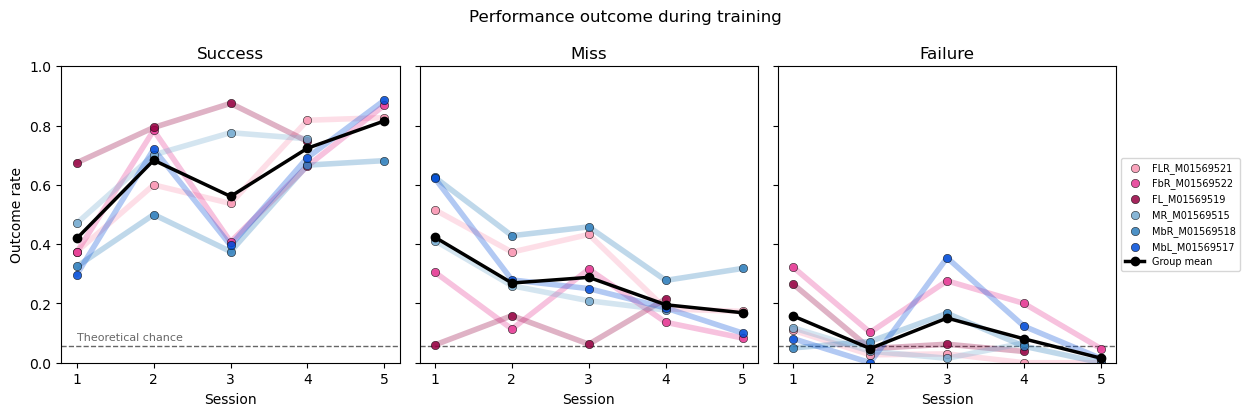

,mouseID,session_index,n_total,n_success,prop_success,n_miss,prop_miss,n_failure,prop_failure,n_success_or_failure,prop_success_or_failure
0,FLR_M01569521,1,64,24,0.375000,33,0.515625,7,0.109375,31,0.484375
1,FLR_M01569521,2,75,45,0.600000,28,0.373333,2,0.026667,47,0.626667
2,FLR_M01569521,3,67,36,0.537313,29,0.432836,2,0.029851,38,0.567164
3,FLR_M01569521,4,121,99,0.818182,22,0.181818,0,0.000000,99,0.818182
4,FLR_M01569521,5,104,86,0.826923,18,0.173077,0,0.000000,86,0.826923
5,FL_M01569519,1,83,56,0.674699,5,0.060241,22,0.265060,78,0.939759
6,FL_M01569519,2,63,50,0.793651,10,0.158730,3,0.047619,53,0.841270
7,FL_M01569519,3,64,56,0.875000,4,0.062500,4,0.062500,60,0.937500
8,FL_M01569519,4,79,59,0.746835,17,0.215190,3,0.037975,62,0.784810
9,FbR_M01569522,1,59,22,0.372881,18,0.305085,19,0.322034,41,0.694915


In [6]:
# Render Figure 1 (uses the 5-day sessions, x-axis = each mouse's Session 1..N).
trials_rate = add_session_index(trials_sessions)
fig, axes, outcome_summary = plot_outcome_panels(trials_rate)
plt.show()
outcome_summary

## Figure 2 | Within-session performance (cumulative)

Cumulative success rate over the trials within a day, one line per **first / mid / last**
day, pooled across the mice you pass in `groups` (a `{name: [mice]}` dict, so you can do
one mouse, a subset, or all mice). Thin lines are individual mice; the bold line is the
group mean per phase.

In [7]:
# Figure 2 | Cumulative within-day success rate, per phase (first / mid / last).
# Colours distinguish the phase; the `groups` keypair selects / pools mice.

DEFAULT_PHASE_COLOURS = {1: '#1b9e77', 2: '#7570b3', 3: '#d95f02'}   # first, mid, last


def cumulative_success_by_trial(trials, *, mouse_col='mouseID', phase_col='training_day',
                                trial_col='day_trial_index', outcome_col='outcome',
                                success_values=('Success',)):
    '''
    Cumulative success rate over trial order within each (mouse, phase).

    ----------
    Parameters:
        trials (pd.DataFrame):
            Trial table with mouse, phase, within-day trial index and outcome columns.
        mouse_col, phase_col, trial_col, outcome_col (str):
            Column names. `phase_col` is training_day (1=first, 2=mid, 3=last).
        success_values (tuple[str]):
            Outcome labels counted as a success. Default ('Success',).
    Returns:
        pd.DataFrame:
            Long table [mouse, phase, trial, cum_rate], one row per trial, where cum_rate
            is successes-so-far / trials-so-far within that (mouse, phase).
    '''
    d = trials.sort_values([mouse_col, phase_col, trial_col]).copy()
    d['_success'] = d[outcome_col].isin(success_values).astype(float)
    grp = d.groupby([mouse_col, phase_col])
    d['cum_rate'] = grp['_success'].cumsum() / (grp.cumcount() + 1)
    return d[[mouse_col, phase_col, trial_col, 'cum_rate']].rename(columns={trial_col: 'trial'})


def plot_cumulative_within_day(trials, *, groups=None, phase_labels=TRAINING_PHASE_LABELS,
                               phase_colours=DEFAULT_PHASE_COLOURS, mouse_col='mouseID',
                               phase_col='training_day', trial_col='day_trial_index',
                               chance_level=1.0 / 18.0, show_individuals=True, ax=None,
                               smooth_window=None, group_linestyles=('-', '--', ':', '-.')):
    '''
    Plot cumulative within-day success rate, one bold mean line per phase per group.

    ----------
    Parameters:
        trials (pd.DataFrame):
            Trial table (typically trials_phase) with mouse, phase, within-day trial
            index and outcome columns.
        groups (dict | None):
            {name: [mice]} to pool. None means one implicit group of every mouse present.
            One bold mean line is drawn per (group, phase); groups are distinguished by
            line style, phases by colour.
        phase_labels (dict):
            {phase_int: label} for the legend, e.g. {1:'first', 2:'mid', 3:'last'}.
        phase_colours (dict):
            {phase_int: colour}.
        mouse_col, phase_col, trial_col (str):
            Column names.
        chance_level (float):
            Height of the dashed theoretical-chance line (default 1/18).
        show_individuals (bool):
            If True, draw a faint line per mouse (coloured by phase) behind the means.
        smooth_window (int | None):
            If set (>1), smooth each bold mean curve with a centred rolling mean over
            this many trials. None (default) leaves the mean unsmoothed.
        ax (matplotlib Axes | None):
            Axis to draw onto; a new figure is made if None.
        group_linestyles (tuple):
            Line styles cycled across groups.
    Returns:
        matplotlib Axes: the axis drawn onto.
    '''
    cum = cumulative_success_by_trial(trials, mouse_col=mouse_col, phase_col=phase_col,
                                      trial_col=trial_col)
    if groups is None:
        groups = {'all': sorted(set(trials[mouse_col]))}
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    selected = set().union(*groups.values())
    group_style = dict(zip(groups, group_linestyles))
    for phase in sorted(trials[phase_col].unique()):
        colour = phase_colours.get(phase)
        cph = cum[cum[phase_col] == phase]
        # Faint individual-mouse curves (only for the mice in the `groups` selection).
        if show_individuals:
            for mname, md_ in cph.groupby(mouse_col):
                if mname not in selected:
                    continue
                md_ = md_.sort_values('trial')
                ax.plot(md_['trial'], md_['cum_rate'], color=colour, alpha=0.18,
                        linewidth=1, zorder=1)
        # Bold group-mean curve per (group, phase). At each trial index the mean is over
        # the mice in the group that reached that many trials.
        for gname, mice in groups.items():
            gd = cph[cph[mouse_col].isin(mice)]
            if gd.empty:
                continue
            mean = gd.groupby('trial')['cum_rate'].mean()
            if smooth_window and smooth_window > 1:
                mean = mean.rolling(smooth_window, center=True, min_periods=1).mean()
            label = f'{phase_labels.get(phase, phase)}' + (f' ({gname})' if len(groups) > 1 else '')
            ax.plot(mean.index, mean.values, color=colour, linewidth=2.8,
                    linestyle=group_style[gname], zorder=3, label=label)

    ax.axhline(chance_level, linestyle='--', color='0.4', linewidth=1, zorder=0)
    ax.set_xlabel('Trials within day')
    ax.set_ylabel('Cumulative success rate')
    ax.set_ylim(0, 1)
    ax.set_title('Within-session performance (cumulative)')
    ax.text(ax.get_xlim()[0], chance_level + 0.02, 'Theoretical chance', fontsize=8, color='0.4')
    ax.legend(fontsize=8, title='Training day')
    return ax

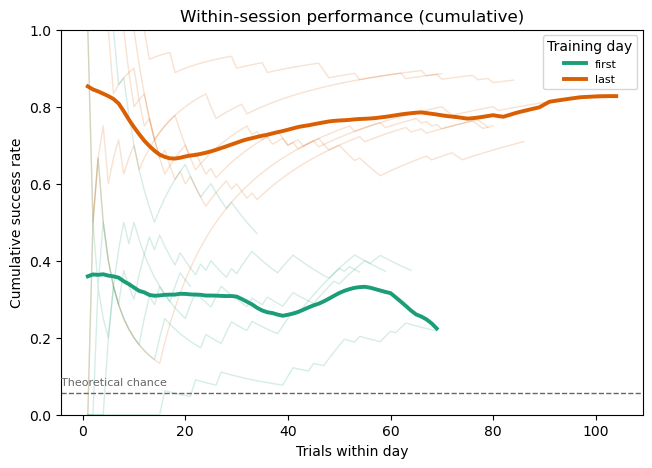

In [8]:
# Render Figure 2. Change `groups` to pick the mice: one mouse, a subset, or all.
#   e.g. groups={'FLR': ['FLR_M01569521']}                      -> one mouse
#        groups={'females': [...], 'males': [...]}              -> compare two groups
groups_all = {'all mice': sorted(trials_phase['mouseID'].unique())}
trials_first_last = trials_phase[trials_phase['training_day'].isin([1, 3])]  # first & last only
fig, ax = plt.subplots(figsize=(7.5, 5))
plot_cumulative_within_day(trials_first_last, groups=groups_all, ax=ax, smooth_window=9)
plt.show()

## Figure 3 | Performance vs search-path duration

Success rate binned by search-path duration (TTT, the outbound time-to-target in
seconds), one panel per **first / mid / last** day. Each mouse is a coloured series and
the black marker is the mean across mice, following Celia's `<10 / 20-30 / >40 s` bins.
This is the same `custom_bin_relationship` helper used in `Requested_plots.ipynb`,
copied here so this notebook is self-contained.

In [9]:
# custom_bin_relationship: copied verbatim from Requested_plots.ipynb (Figure 2.4).
# Success rate per USER-DEFINED value bin (explicit ranges), per group, with a
# mean-of-groups series and a pooled least-squares fit.
def custom_bin_relationship(
        trials, *, value_col, bin_groups, groups,
        response='success_rate', mouse_column='mouseID', ax=None,
        show_points=True, show_mean=True, show_regression=True, show_boxplots=False,
        colors=None, mean_color='black', reg_color='crimson', jitter=0.0, min_trials=1):
    '''Per-bin response for USER-DEFINED value ranges, per group, + mean & regression.

    value_col  : column to bin on (e.g. 'TTT').
    bin_groups : {label: (low, high)} dict (order preserved); a trial is in a bin if
                 low <= value < high. Use -np.inf / np.inf for open ends, leave gaps to
                 skip ranges. A list of (low, high[, label]) tuples also works.
    groups     : {name: [mice]} -> one coloured series each.
    response   : 'success_rate' (fraction outcome=='Success') or a numeric column mean.

    Returns (ax, tables) with tables['by_group'], tables['by_bin'], tables['regression'].
    '''
    if isinstance(bin_groups, dict):
        bins = [(rng[0], rng[1], name) for name, rng in bin_groups.items()]
    else:
        bins = list(bin_groups)

    d = trials.copy()
    d['_success'] = (d['outcome'] == 'Success').astype(float)
    resp = '_success' if response == 'success_rate' else response
    d = d.dropna(subset=[value_col, resp])

    def label(b):
        if len(b) > 2:
            return b[2]
        lo, hi = b[0], b[1]
        if lo == -np.inf:
            return f'<{hi:g}'
        if hi == np.inf:
            return f'>{lo:g}'
        return f'{lo:g}-{hi:g}'

    labels = [label(b) for b in bins]
    centres = np.arange(len(bins))

    grp_vals = {}
    by_group_rows = []
    for gname, mice in groups.items():
        gd = d[d[mouse_column].isin(mice)]
        vals = []
        for (lo, hi, *_), lab in zip(bins, labels):
            sub = gd[(gd[value_col] >= lo) & (gd[value_col] < hi)]
            vals.append(sub[resp].mean() if len(sub) >= min_trials else np.nan)
            by_group_rows.append({'bin': lab, 'group': gname, 'n': int(len(sub)),
                                  'success_rate': sub[resp].mean() if len(sub) else np.nan,
                                  'mean_value': sub[value_col].mean() if len(sub) else np.nan})
        grp_vals[gname] = vals

    by_bin_rows = []
    for bi, (lo, hi, *_) in enumerate(bins):
        allsub = d[(d[value_col] >= lo) & (d[value_col] < hi)]
        grpsr = [grp_vals[g][bi] for g in grp_vals if pd.notna(grp_vals[g][bi])]
        by_bin_rows.append({'bin': labels[bi], 'n_total': int(len(allsub)),
                            'n_groups': len(grpsr),
                            'SR_pooled': allsub[resp].mean() if len(allsub) else np.nan,
                            'SR_mean_of_groups': np.mean(grpsr) if grpsr else np.nan})

    xp, yp = [], []
    for vals in grp_vals.values():
        for bi, v in enumerate(vals):
            if pd.notna(v):
                xp.append(centres[bi]); yp.append(v)
    xp, yp = np.asarray(xp, float), np.asarray(yp, float)
    reg = None
    if len(xp) >= 2 and np.ptp(xp) > 0:
        slope, intercept = np.polyfit(xp, yp, 1)
        reg = {'slope': slope, 'intercept': intercept,
               'r': float(np.corrcoef(xp, yp)[0, 1]), 'n_points': int(len(xp))}

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4.5))

    if show_boxplots:
        data, pos = [], []
        for bi in range(len(bins)):
            v = [grp_vals[g][bi] for g in grp_vals if pd.notna(grp_vals[g][bi])]
            if v:
                data.append(v); pos.append(centres[bi])
        if data:
            ax.boxplot(data, positions=pos, widths=0.5, showfliers=False, zorder=1,
                       medianprops=dict(color='grey'), boxprops=dict(color='grey'),
                       whiskerprops=dict(color='grey'), capprops=dict(color='grey'))

    if show_points:
        n = len(grp_vals)
        for k, (gname, vals) in enumerate(grp_vals.items()):
            off = (k - (n - 1) / 2) * jitter
            ax.scatter(centres + off, vals, s=22, color=(colors or {}).get(gname),
                       label=gname, zorder=3)

    if show_mean:
        mean_bin = [np.nanmean([grp_vals[g][bi] for g in grp_vals])
                    if any(pd.notna(grp_vals[g][bi]) for g in grp_vals) else np.nan
                    for bi in range(len(bins))]
        ax.plot(centres, mean_bin, marker='o', ls='none', color=mean_color, ms=8,
                mec='white', mew=0.8, label='mean across mice', zorder=4)

    if show_regression and reg is not None:
        xr = np.array([centres[0], centres[-1]])
        ax.plot(xr, reg['slope'] * xr + reg['intercept'], '--', color=reg_color, lw=2,
                zorder=5, label='linear regression (all groups)')
        ax.text(0.03, 0.04, f"r={reg['r']:.2f}", transform=ax.transAxes, va='bottom',
                fontsize=9, color=reg_color,
                bbox=dict(boxstyle='round', fc='white', alpha=0.6, ec='none'))

    ax.set_xticks(centres); ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, len(bins) - 0.5)
    ax.set_xlabel(value_col)
    ax.set_ylabel('success rate' if response == 'success_rate' else response)

    tables = {'by_group': pd.DataFrame(by_group_rows),
              'by_bin': pd.DataFrame(by_bin_rows), 'regression': reg}
    return ax, tables

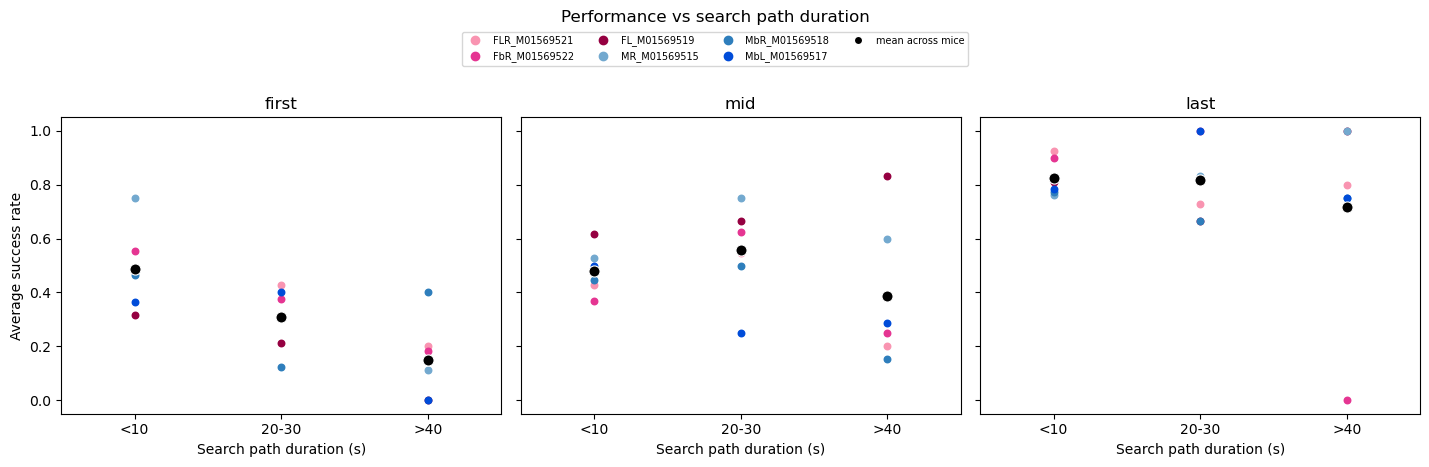

In [10]:
# Render Figure 3. Each mouse is its own group (coloured series); the black marker is
# the mean across mice. Bins are Celia's <10 / 20-30 / >40 s (gaps 10-20 and 30-40 skipped).
TTT_BIN_GROUPS = {'<10': (-np.inf, 10), '20-30': (20, 30), '>40': (40, np.inf)}

GROUPS = {m: [m] for m in DEFAULT_MOUSE_COLOURS if m in set(trials_phase['mouseID'])}
COLORS = {m: DEFAULT_MOUSE_COLOURS[m] for m in GROUPS}

phases = sorted(trials_phase['training_day'].unique())
fig, axes = plt.subplots(1, len(phases), figsize=(4.8 * len(phases), 4.2),
                         squeeze=False, sharey=True)
axes = axes[0]
for ax, phase in zip(axes, phases):
    custom_bin_relationship(
        trials_phase[trials_phase['training_day'] == phase],
        value_col='TTT', bin_groups=TTT_BIN_GROUPS, groups=GROUPS, colors=COLORS,
        ax=ax, show_regression=False)
    ax.set_title(TRAINING_PHASE_LABELS.get(phase, phase))
    ax.set_xlabel('Search path duration (s)')
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('')
axes[0].set_ylabel('Average success rate')

handles = [Line2D([0], [0], marker='o', ls='', color=COLORS[m], label=m) for m in GROUPS]
handles.append(Line2D([0], [0], marker='o', ls='', color='black', mec='white',
                      label='mean across mice'))
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=7, bbox_to_anchor=(0.5, 1.06))
fig.suptitle('Performance vs search path duration', y=1.10)
fig.tight_layout()
plt.show()

## Figure 4 | Shaping days per mouse

The number of shaping days is **not** in the trial table; it is the count of shaping
session sub-folders per mouse on the acquisition drive. `count_shaping_days` walks that
tree (adjust `SHAPING_ROOT` and the folder layout to match the device), so this figure
only fills in when run on the data PC. On a machine without the tree it draws an empty
placeholder.

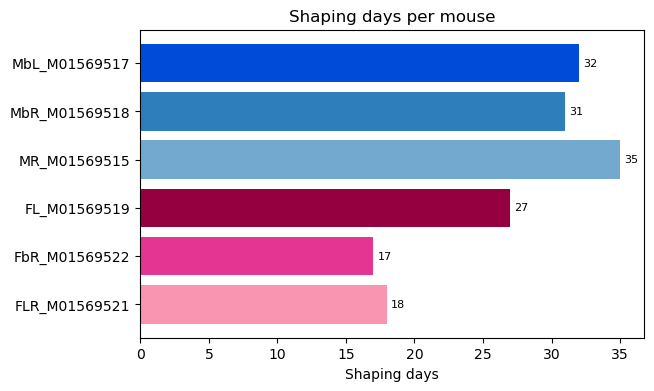

{'FLR_M01569521': 18,
 'FbR_M01569522': 17,
 'FL_M01569519': 27,
 'MR_M01569515': 35,
 'MbR_M01569518': 31,
 'MbL_M01569517': 32}

In [11]:
# Figure 4 | Shaping-days bar chart.
# Point SHAPING_ROOT at the shaping tree on the data PC. The default layout assumes one
# folder per shaping day directly under <SHAPING_ROOT>/<mouseID>/; adjust `pattern` /
# the glob if the real layout differs.
SHAPING_ROOT = pathlib.Path('/media/sepi/Elements1/PathIntegrationProtocol/BonsaiOutput/Shaping')


def count_shaping_days(shaping_root, mice, *, pattern='*'):
    '''
    Count shaping-day sub-folders per mouse under `shaping_root/<mouse>/`.

    ----------
    Parameters:
        shaping_root (pathlib.Path | str):
            Root of the shaping tree on the acquisition drive.
        mice (list[str]):
            Mouse IDs (sub-folder names) to count.
        pattern (str):
            Glob for the day folders under each mouse. Default '*' (all sub-folders).
    Returns:
        dict[str, float]:
            {mouseID: n_days}; NaN for a mouse whose folder is not found.
    '''
    shaping_root = pathlib.Path(shaping_root)
    counts = {}
    for mouse in mice:
        mouse_dir = shaping_root / mouse
        counts[mouse] = (
            sum(1 for p in mouse_dir.glob(pattern) if p.is_dir())
            if mouse_dir.exists() else np.nan
        )
    return counts


def plot_shaping_days(counts, *, mouse_colours=DEFAULT_MOUSE_COLOURS, ax=None):
    '''
    Horizontal bar chart of shaping-day counts per mouse.

    ----------
    Parameters:
        counts (dict[str, float]):
            {mouseID: n_days}, e.g. from count_shaping_days.
        mouse_colours (dict):
            {mouseID: colour}; order sets the bar order (F-named pink, M-named blue).
        ax (matplotlib Axes | None):
            Axis to draw onto; a new figure is made if None.
    Returns:
        matplotlib Axes: the axis drawn onto.
    '''
    mice = [m for m in mouse_colours if m in counts]
    values = [counts[m] for m in mice]
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    if not any(pd.notna(v) for v in values):
        ax.text(0.5, 0.5, 'No shaping-day counts found.\nRun count_shaping_days on the data PC.',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return ax
    y = np.arange(len(mice))
    ax.barh(y, values, color=[mouse_colours[m] for m in mice])
    for yi, v in zip(y, values):
        if pd.notna(v):
            ax.text(v + 0.3, yi, str(int(v)), va='center', fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels(mice)
    ax.set_xlabel('Shaping days')
    ax.set_title('Shaping days per mouse')
    return ax


shaping_counts = count_shaping_days(SHAPING_ROOT, list(DEFAULT_MOUSE_COLOURS))
fig, ax = plt.subplots(figsize=(6.5, 4))
plot_shaping_days(shaping_counts, ax=ax)
plt.show()
shaping_counts